# Implement folder Planck equation
Find optimal concentration schedule / optimal antigen using analytical formula



In [1]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np

from fokker_planck import run_fp, plot_fp_density_time_dim



Running FP simulation for T=140 seconds


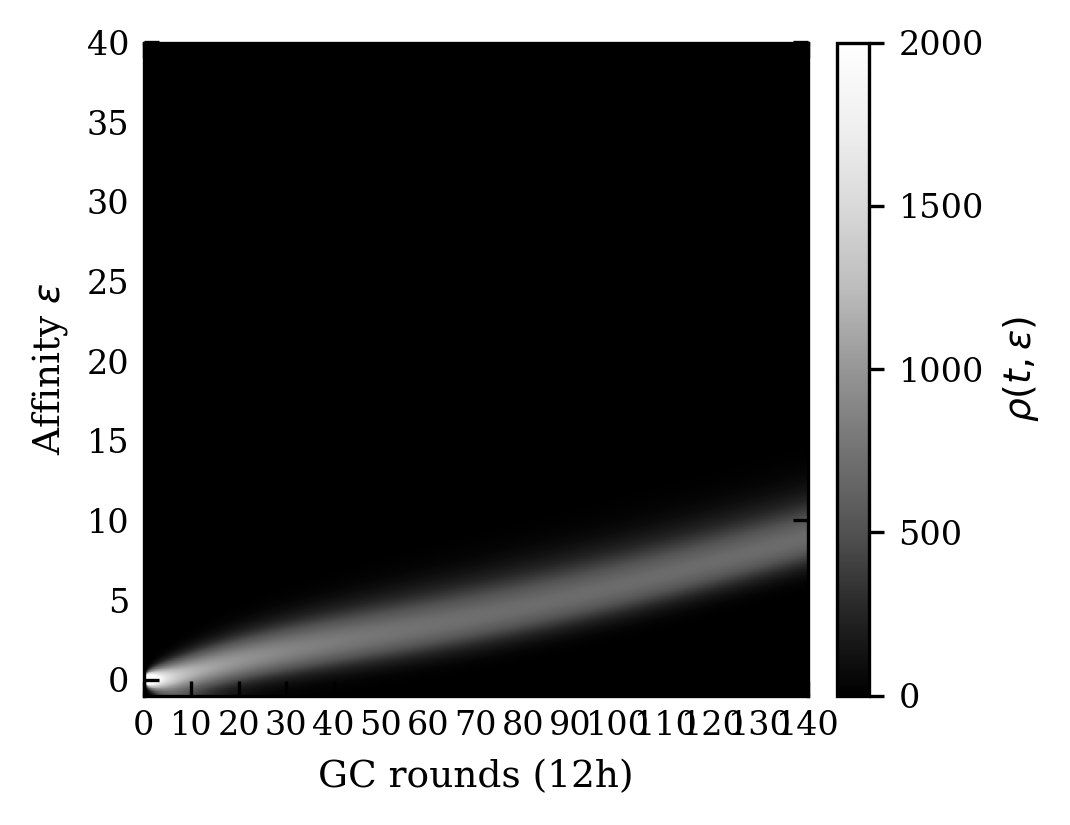

In [2]:
import numpy as np
import copy
T=140
print(f"\nRunning FP simulation for T={T} seconds")
fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")







# Injection optim

In [3]:
import pandas as pd
df=pd.read_csv("c_star_over_time.csv")
times=df['time'].values
c_star=df['c_star'].values

print(times)

[0.00000e+00 5.00000e-03 1.00000e-02 ... 1.39990e+02 1.39995e+02
 1.40000e+02]


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class ImmunizationOptimizer(nn.Module):
    def __init__(self, N, tau, initial_C_values, initial_interval_values):
        super().__init__()
        self.N = N
        self.tau = float(tau)
        
        # Helper for inverse softplus: x = ln(exp(y) - 1)
        def inverse_softplus(y):
            return np.log(np.exp(y) + 1e-6 - 1)

        # 1. Parameter for Concentrations (log_C)
        # We initialize in log space. max() ensures we don't take log of 0 or negative numbers.
        init_log_C = [np.log(max(val, 1e-8)) for val in initial_C_values]
        self.log_C = nn.Parameter(torch.tensor(init_log_C, dtype=torch.float32))
        
        # 2. Parameter for Time Intervals (dt)
        if N > 1:
            init_dt_raw = [inverse_softplus(val) for val in initial_interval_values]
            self.raw_dt = nn.Parameter(torch.tensor(init_dt_raw, dtype=torch.float32))
        else:
            self.raw_dt = None

    def get_physical_parameters(self):
        # Ensure Positive Concentrations by taking the exponential of the log parameter
        C_i = torch.exp(self.log_C)
        
        # Construct Times from Intervals
        t_1 = torch.tensor([0.0], device=self.log_C.device)
        if self.N > 1:
            intervals = torch.nn.functional.softplus(self.raw_dt)
            later_times = torch.cumsum(intervals, dim=0)
            t_i = torch.cat([t_1, later_times])
        else:
            t_i = t_1
            
        return C_i, t_i

    def forward(self, t_eval, sigmoid_steepness=50.0):
        C_i, t_i = self.get_physical_parameters()
        
        t_eval = t_eval.view(-1, 1)
        t_i = t_i.view(1, -1)
        C_i = C_i.view(1, -1)
        
        dt = t_eval - t_i
        
        # Differentiable Step Function
        step_approx = torch.sigmoid(sigmoid_steepness * dt)
        
        # FIX: Use ReLU to prevent exponential explosion for t < t_i
        # It forces the decay term to 1.0 before the injection, which is then 
        # safely zeroed out by the step_approx multiplier.
        safe_dt = torch.relu(dt)
        decay = torch.exp(-safe_dt / self.tau)
        
        concentration_matrix = step_approx * C_i * decay
        C_total = torch.sum(concentration_matrix, dim=1)
        
        return C_total


def find_optimal_parameters(N, tau, t_eval_array, C_star_array, epochs=4000, lr=0.1):
    # Base interval assumption for initialization
    interval_guess = 20.0
    init_intervals = [interval_guess] * (N - 1)
    init_C_values = []
    
    for i in range(N):
        expected_time = i * interval_guess
        idx = (np.abs(t_eval_array - expected_time)).argmin()
        
        # Get the target value at this time step
        target_val = max(float(C_star_array[idx]), 1e-4)
        
        # Analytically scale the initialization to prevent underdose during the interval
        # C_initial = C_target * exp(dt / tau)
        safe_val = target_val * np.exp(interval_guess / tau)
        
        init_C_values.append(safe_val)

    t_tensor = torch.tensor(t_eval_array, dtype=torch.float32)
    C_star_tensor = torch.tensor(C_star_array, dtype=torch.float32)
    
    model = ImmunizationOptimizer(N, tau, init_C_values, init_intervals)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # --- Barrier Hyperparameters ---
    # barrier_weight (lambda): Scales the overall impact of the penalty.
    # barrier_steepness (gamma): Controls how fast the wall shoots up.
    barrier_weight = 100.0  
    barrier_steepness = 10.0 

    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Annealing
        current_steepness = 10.0 + (90.0 * epoch / epochs)
        
        C_simulated = model(t_tensor, sigmoid_steepness=current_steepness)
        
        # Compute Log Difference
        log_C_simulated = torch.log(C_simulated + 1e-8)
        log_C_star = torch.log(C_star_tensor + 1e-8)
        
        # 1. Base MSE (handles general curve fitting and over-dosing)
        mse_loss = torch.mean((log_C_simulated - log_C_star) ** 2)
        
        # 2. Exponential Barrier (handles under-dosing)
        # ReLU ensures this is only > 0 when C_simulated < C_star
        underdose_amount = torch.relu(log_C_star - log_C_simulated)
        
        # Clamp the underdose amount to prevent exponential overflow (NaNs) early in training
        underdose_amount_clamped = torch.clamp(underdose_amount, max=5.0)
        
        # barrier_penalty = torch.mean(barrier_weight * (torch.exp(barrier_steepness * underdose_amount_clamped) - 1.0))
        mse_underdose=torch.mean(underdose_amount_clamped ** 2)* barrier_weight
        # Combine losses
        loss = mse_loss + mse_underdose

        loss.backward()
        
        # Gradient clipping is crucial here so the exponential penalty doesn't destabilize Adam
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step()

    final_C, final_t = model.get_physical_parameters()
    
    return {
        "C_optimized": final_C.detach().numpy(),
        "t_optimized": final_t.detach().numpy(),
        "final_loss": loss.item(),
        'C_simulated': C_simulated.detach().numpy()
    }

In [5]:
tau_val = 20.0

N_injections = 1

result1 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result1['C_optimized'])
print("Optimized Times (t):", result1['t_optimized'])

N_injections = 2

result2 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result2['C_optimized'])
print("Optimized Times (t):", result2['t_optimized'])

N_injections = 3

result3 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result3['C_optimized'])
print("Optimized Times (t):", result3['t_optimized'])




Final Result:
Optimized Injections (C): [1584.6793]
Optimized Times (t): [0.]

Final Result:
Optimized Injections (C): [91.24023 44.56984]
Optimized Times (t): [ 0.      76.80806]

Final Result:
Optimized Injections (C): [60.688972 11.752397 11.813028]
Optimized Times (t): [  0.       66.3788  103.07412]


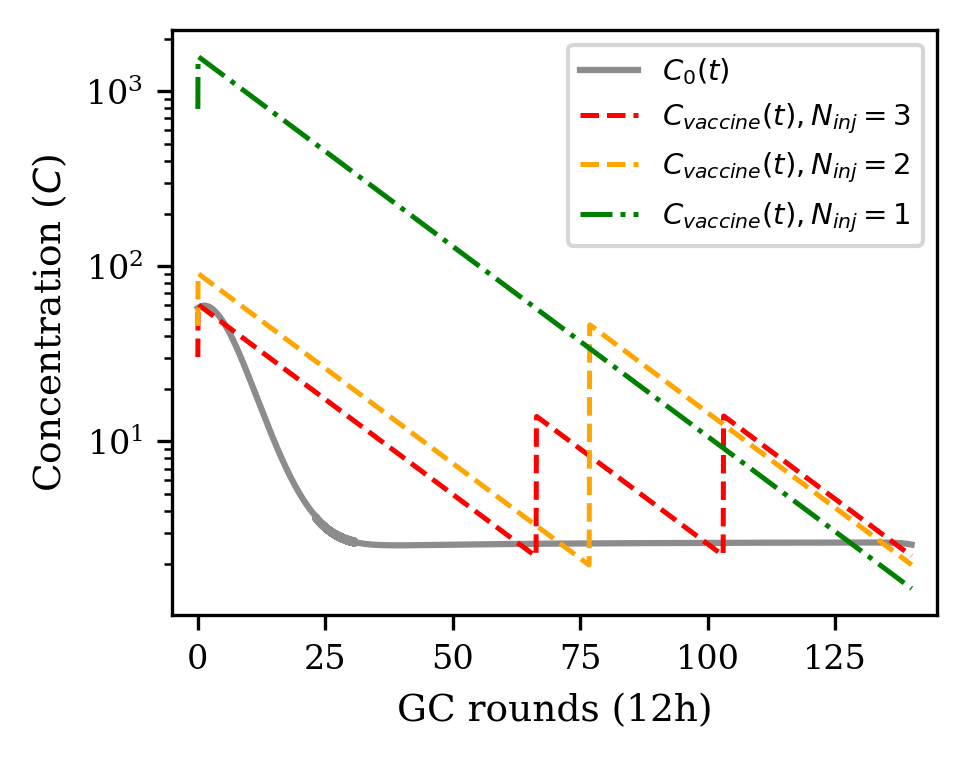

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Setup Plotting Style (Matching your template)
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})

# ---------------------------------------------------------
# 2. Extract Data from Optimization Result
# ---------------------------------------------------------
# Assuming 'result' dictionary is available from the previous step
# and 't_data' and 'C_target' are the original inputs.



t_inj2 = result2['t_optimized']  # Injection times
C_inj2 = result2['C_optimized']  # Injection doses (optional to visualize)
C_sim2 = result2['C_simulated'].flatten() # Simulated Response

t_inj1 = result1['t_optimized']  # Injection times
C_inj1 = result1['C_optimized']  # Injection doses (optional to visualize)
C_sim1 = result1['C_simulated'].flatten() # Simulated Response

t_inj3 = result3['t_optimized']  # Injection times
C_inj3 = result3['C_optimized']  # Injection doses (optional to visualize)
C_sim3 = result3['C_simulated'].flatten() # Simulated Response

t_sim = times
C_ref = c_star

# ---------------------------------------------------------
# 3. Create Figure and Axes
# ---------------------------------------------------------
fig, ax = plt.subplots()

# ---------------------------------------------------------
# 4. Plot the Curves
# ---------------------------------------------------------

# Target C* (Dashed, Lighter Blue)
ax.plot(t_sim, C_ref, 
        label=r"$C_0(t)$", 
        color='grey',       # Soft Blue
        linestyle='-', 
        linewidth=1.5,
        alpha=0.9)

# Simulated C (Solid, Darker/Rich Blue)
ax.plot(t_sim, C_sim3, 
        label=r"$C_{vaccine}(t), N_{inj}=3$",
        color='red',       # Navy Blue
        linestyle='--', 
        linewidth=1.2)

ax.plot(t_sim, C_sim2, 
        label=r"$C_{vaccine}(t), N_{inj}=2$",
        color='orange',       # Navy Blue
        linestyle='--', 
        linewidth=1.2)


ax.plot(t_sim, C_sim1, 
        label=r"$C_{vaccine}(t), N_{inj}=1$",
        color='green',       # Navy Blue
        linestyle='-.', 
        linewidth=1.2)


# ---------------------------------------------------------
# 5. Add Injection Lines
# ---------------------------------------------------------
# Loop to plot lines, but only add label to legend once
# for i, t_val in enumerate(t_inj):
#     label = "Injection" if i == 0 else None
#     ax.axvline(x=t_val, 
#                color='black', # Nice Red
#                linestyle=':', 
#                linewidth=1.0, 
#                label=label)

# Optional: Add small triangles at the top to emphasize injection timing
# ax.plot(t_inj, [ax.get_ylim()[1]]*len(t_inj), 
#         marker='v', color='#D0021B', linestyle='None', markersize=3, clip_on=False)

# ---------------------------------------------------------
# 6. Formatting & Labels
# ---------------------------------------------------------
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Concentration ($C$)")
ax.set_xlim(t_sim[0], t_sim[-1])
# ax.set_ylim(bottom=0)  # Concentration cannot be negative
plt.yscale("log")  # Log scale for better visibility of differences

# Ticks pointing inwards (Your preference)
# ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

# Legend (No frame, best location)
ax.legend(frameon=True, loc='best', fontsize=7)

# ---------------------------------------------------------
# 7. Final Output
# ---------------------------------------------------------
fig.tight_layout()
plt.xlim(-5, 145)

plt.show()
# Optional: Save
# fig.savefig("optimization_result.pdf", format='pdf', bbox_inches='tight')

In [7]:
def make_get_C_from_cstar(times, c_star):
    times = np.asarray(times, dtype=float)
    c_star = np.asarray(c_star, dtype=float)
    t0, tf = float(times[0]), float(times[-1])

    def get_C_star(t, v):
        # same concentration for all antigens v
        t = float(t)
        if t <= t0:
            return float(c_star[0])
        if t >= tf:
            return float(c_star[-1])
        return float(np.interp(t, times, c_star))
    return get_C_star


In [8]:
get_C_star_vacc1 = make_get_C_from_cstar(times, C_sim1)
get_C_star_vacc2 = make_get_C_from_cstar(times, C_sim2)
get_C_star_vacc3 = make_get_C_from_cstar(times, C_sim3)
get_C_star=make_get_C_from_cstar(times, c_star)

#save as csv
df_vacc = pd.DataFrame({"time": times, "C_vaccine_Ninj3": C_sim3, "C_vaccine_Ninj2": C_sim2, "C_vaccine_Ninj1": C_sim1})
df_vacc.to_csv("optimized_vaccine_concentration.csv", index=False)


In [9]:


fp_ctx_mean = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:C_ref.mean(),
    T=T,
    verbose=False
)

fp_ctx_fixed = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:170,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc1 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc1,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc2 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc2,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc3 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc3,
    T=T,
    verbose=False
)

fp_ctx_opt = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)

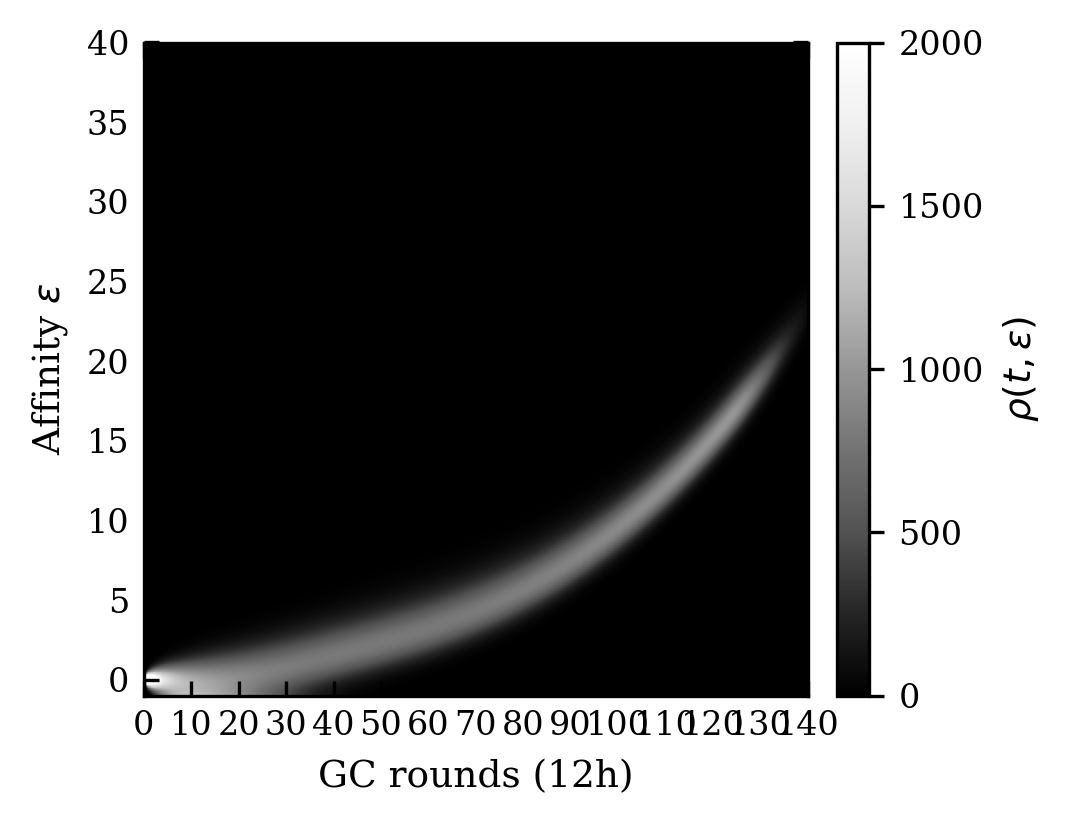

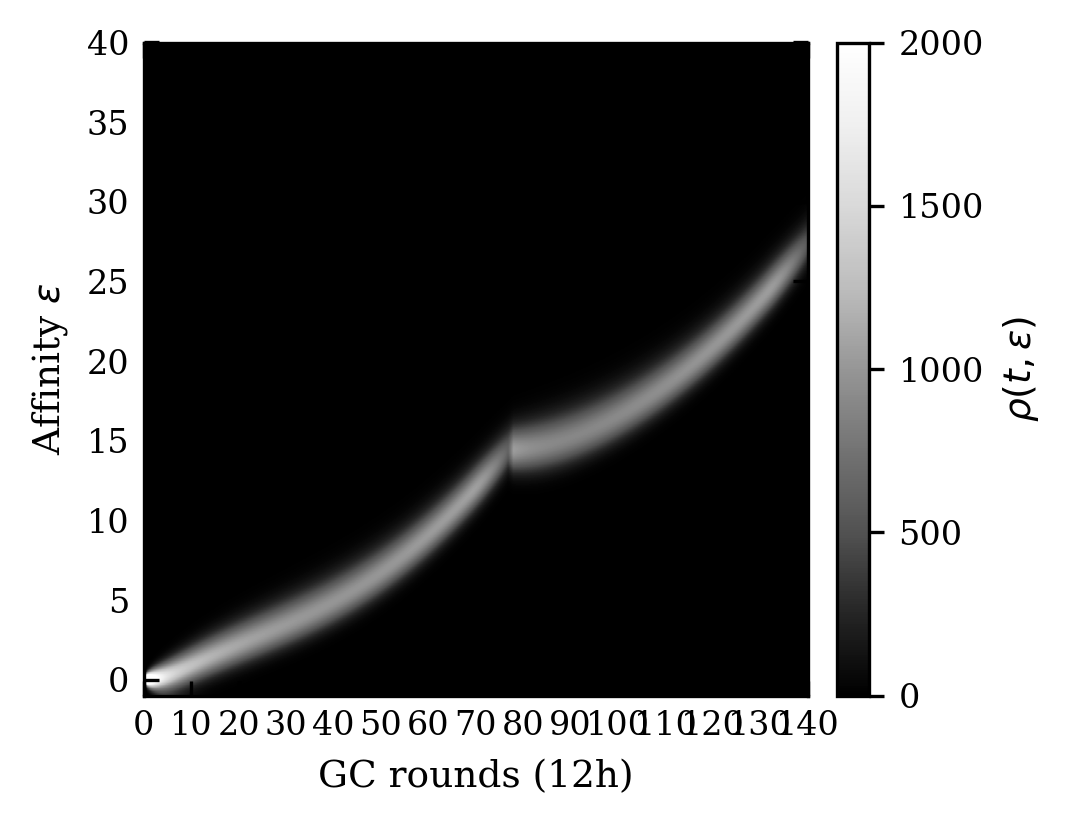

In [12]:
plot_fp_density_time_dim(fp_ctx_opt_vacc1, sol=None, disp_step=10, cmap="Greys_r")
plot_fp_density_time_dim(fp_ctx_opt_vacc2, sol=None, disp_step=10, cmap="Greys_r")

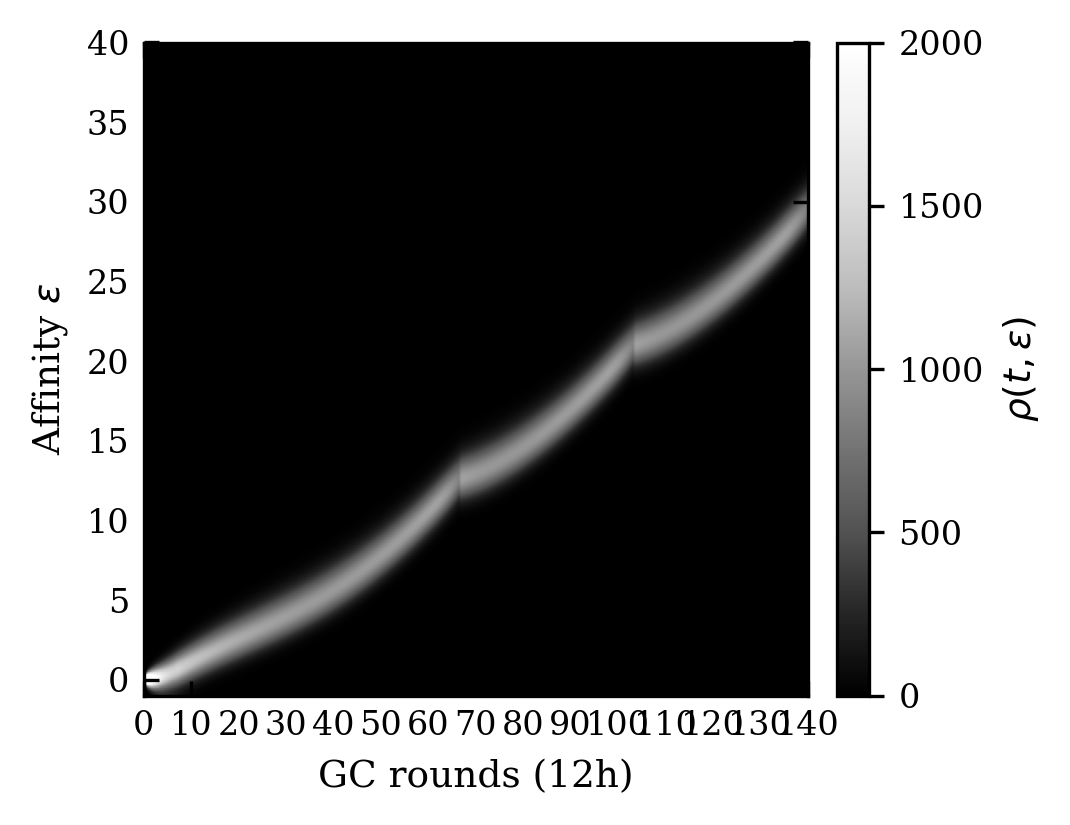

In [13]:
plot_fp_density_time_dim(fp_ctx_opt_vacc3, sol=None, disp_step=10, cmap="Greys_r")


In [ ]:
def _marginal_last(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the last snapshot in fp_ctx 
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element

    rho_stack = fp_ctx["rho_t"]
    
    # Boolean mask for the region strictly above h_c on the h1 axis
    
    best_index = -1
    
 

    rho_alive = rho_stack[best_index]

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

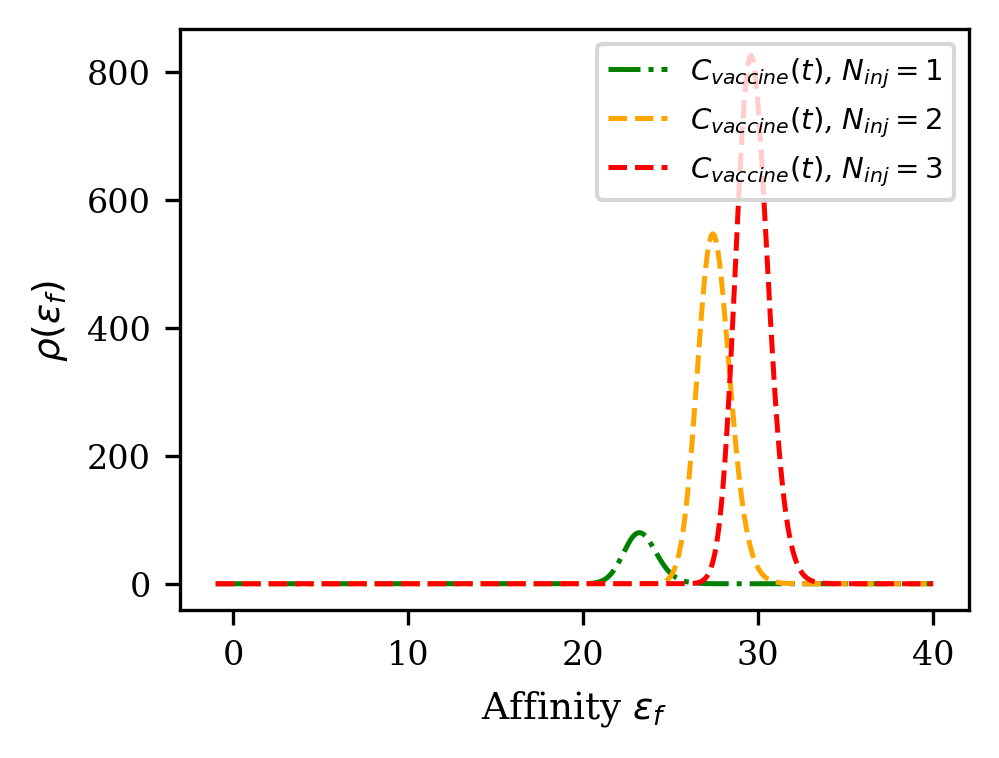

In [ ]:

import numpy as np
import matplotlib.pyplot as plt


# --- get marginals for each schedule ---
h1_opt,   pdf_opt   = _marginal_last(fp_ctx_opt)
h1_mean,  pdf_mean  = _marginal_last(fp_ctx_mean)
h1_fixed, pdf_fixed = _marginal_last(fp_ctx_fixed)
h1_opt_vacc1, pdf_opt_vacc1 = _marginal_last(fp_ctx_opt_vacc1)
h1_opt_vacc2, pdf_opt_vacc2 = _marginal_last(fp_ctx_opt_vacc2)
h1_opt_vacc3, pdf_opt_vacc3 = _marginal_last(fp_ctx_opt_vacc3)

# sanity: same h1 grid
assert np.allclose(h1_opt, h1_mean) and np.allclose(h1_opt, h1_fixed), "h1 grids differ."

# --- plot ---
import matplotlib.pyplot as plt

# 1. Apply your preferred formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using different linestyles helps distinguish curves in small/B&W figures
# ax.plot(h1_opt,   pdf_opt,   label=r"$C_0(t)$",               linestyle='-',  linewidth=1.2)
# ax.plot(h1_mean,  pdf_mean,  label=r"$\langle C_0(t)\rangle_t$", linestyle='--', linewidth=1.2, color='blue')
ax.plot(h1_opt_vacc1, pdf_opt_vacc1, label=r"$C_{vaccine}(t)$, $N_{inj}=1$",                linestyle='-.',  linewidth=1.2, color='green')
ax.plot(h1_opt_vacc2, pdf_opt_vacc2, label=r"$C_{vaccine}(t)$, $N_{inj}=2$",                linestyle='--',  linewidth=1.2, color='orange')
ax.plot(h1_opt_vacc3, pdf_opt_vacc3, label=r"$C_{vaccine}(t)$, $N_{inj}=3$",                linestyle='--',  linewidth=1.2, color='red')

# 4. Set Limits and Labels
# ax.set_xlim(2, 14)
ax.set_xlabel(r"Affinity $\epsilon_f$")
ax.set_ylabel(r"$\rho(\epsilon_f)$")
# ax.set_title(r"Marginal density of $h_1$")

# 5. Apply aesthetic preferences (ticks in, no grid)
# ax.tick_params(direction="in", top=True, right=True) # Added top/right ticks which usually accompany 'in'
ax.grid(False)

# 6. Legend and Layout
# frameon=False usually looks cleaner in small academic plots
ax.legend(frameon=True, loc='upper right', fontsize=7)


fig.tight_layout()
plt.show()


# High affinity as a function of Tau and N_inj

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N_inj_array = [1,2, 3]
Tau_array = [10,20,30,40]

# Dictionary to store results mapped by number of injections
results = {n: [] for n in N_inj_array}

for N_injections in N_inj_array:
    for tau_val in Tau_array:
        
        result = find_optimal_parameters(N_injections, tau_val, times, c_star)
        C_sim = result['C_simulated'].flatten() 
        print (f"Completed optimization for N={N_injections}, tau={tau_val}.")
        print(f"Optimized C values: {result['C_optimized']}")
        concentrations = result['C_optimized']
        injection_times = result['t_optimized']
        
        get_C_star_vacc = make_get_C_from_cstar(times, C_sim)

        fp_ctx_opt_vacc = run_fp(
            get_S=lambda t: np.array([[1.0]]),  
            get_C=get_C_star_vacc,
            T=T,
            verbose=False, 
            
        )
        
        h1_opt, pdf_opt = _marginal_last(fp_ctx_opt_vacc)
     

        mean = np.average(h1_opt, weights=pdf_opt)
        if np.isnan(mean):
            print("nan")
            mean = 0.0
        print(f"Mean h1 for N={N_injections}, tau={tau_val}: {mean:.2f}")
        #if nan: replace with 0
        
        # Store the (tau, density) pair for plotting
        results[N_injections].append((tau_val, mean, concentrations, injection_times))


Completed optimization for N=1, tau=10.
Optimized C values: [922153.1]
Mean h1 for N=1, tau=10: 20.83
Completed optimization for N=1, tau=20.
Optimized C values: [1584.6793]
Mean h1 for N=1, tau=20: 23.31
Completed optimization for N=1, tau=30.
Optimized C values: [189.85156]
Mean h1 for N=1, tau=30: 25.83
Completed optimization for N=1, tau=40.
Optimized C values: [65.749405]
Mean h1 for N=1, tau=40: 27.78
Completed optimization for N=2, tau=10.
Optimized C values: [2187.2017 1121.4551]
Mean h1 for N=2, tau=10: 23.19
Completed optimization for N=2, tau=20.
Optimized C values: [91.24023 44.56984]
Mean h1 for N=2, tau=20: 27.51
Completed optimization for N=2, tau=30.
Optimized C values: [53.910767  8.057172]
Mean h1 for N=2, tau=30: 29.32
Completed optimization for N=2, tau=40.
Optimized C values: [48.01066    1.7922413]
Mean h1 for N=2, tau=40: 29.02
Completed optimization for N=3, tau=10.
Optimized C values: [358.90323 132.26868 133.83119]
Mean h1 for N=3, tau=10: 25.51
Completed opti

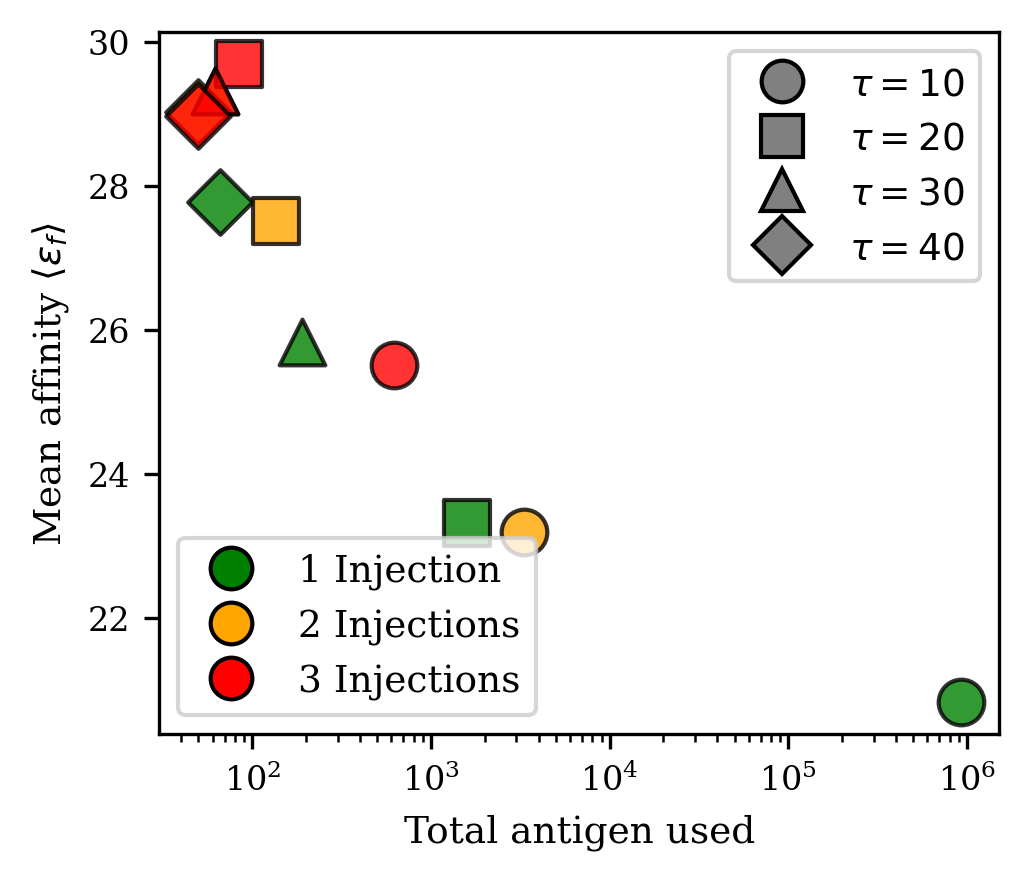

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

plt.figure(figsize=(3.5, 3))

# Define colors mapped to Number of Injections
colors_inj = {1: 'green', 2: 'orange', 3: 'red'}
labels_inj = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

# Define markers mapped to Tau values
markers_tau = {10.0: 'o', 20.0: 's', 30.0: '^', 40.0: 'D'}
# labels_tau={10.0: 'Tau = 10', 20.0: 'Tau = 20', 30.0: 'Tau = 30', 40.0: 'Tau = 40'}
#:latex
labels_tau = {10.0: r'$\tau=10$', 20.0: r'$\tau=20$', 30.0: r'$\tau=30$', 40.0: r'$\tau=40$'}

# Loop through the data to plot each point
for N_injections in N_inj_array:
    current_results = results[N_injections]
    
    for item in current_results:
        tau_val = item[0]
        mean = item[1]
        concentrations = item[2]
        
        # Total antigen is the sum of all optimized C values
        total_antigen = np.sum(concentrations)
        
        plt.scatter(
            total_antigen, 
            mean, 
            marker=markers_tau[tau_val], 
            color=colors_inj[N_injections],
            s=120,
            alpha=0.8,
            edgecolors='k' # Add a black edge for better visibility
        )

# --- Create Custom Legends ---

# 1. Legend for Number of Injections (Colors, keeping marker neutral)
legend_elements_inj = [
    mlines.Line2D([0], [0], marker='o', color='w', label=labels_inj[n], 
                  markerfacecolor=colors_inj[n], markeredgecolor='k', markersize=10) 
    for n in N_inj_array
]

# 2. Legend for Tau (Markers, keeping color neutral)
legend_elements_tau = [
    mlines.Line2D([0], [0], marker=markers_tau[t], color='w', label=labels_tau[t], 
                  markerfacecolor='gray', markeredgecolor='k', markersize=10) 
    for t in Tau_array
]

# Add the first legend (Injections) and anchor it
leg1 = plt.legend(handles=legend_elements_inj, loc='lower left')
plt.gca().add_artist(leg1) 

# Add the second legend (Tau)
plt.legend(handles=legend_elements_tau, 
        #    title='Tau (Half-life)', loc='best')
        #latex
         loc='best')

plt.xlabel('Total antigen used')
# plt.ylabel('Mean Affinity <\epsilon_f>')
#latex
plt.ylabel(r'Mean affinity $\langle \epsilon_f \rangle$')
# plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.xscale('log')  # Log scale for better visibility of differences
plt.show()

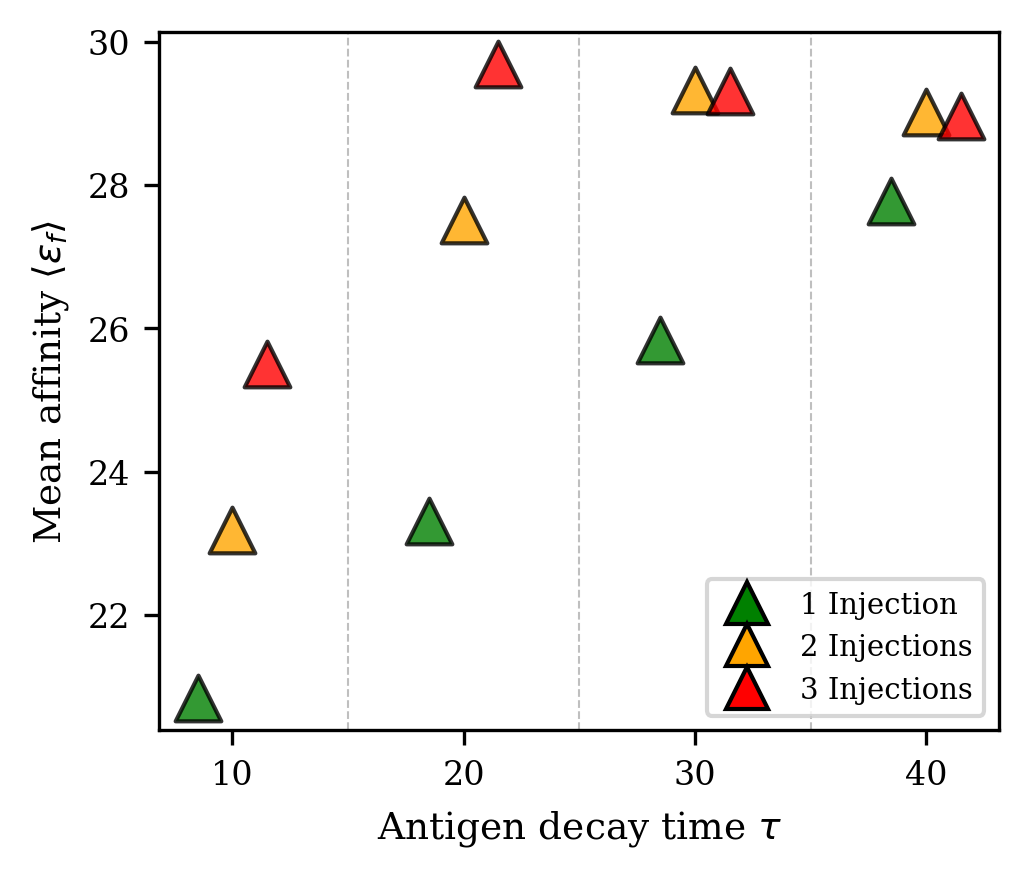

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

plt.figure(figsize=(3.5, 3))

# Define colors mapped to Number of Injections
colors_inj = {1: 'green', 2: 'orange', 3: 'red'}
labels_inj = {1: '1 Injection', 2: '2 Injections', 3: '3 Injections'}

# Define offsets mapped to Number of Injections to prevent overlap
# Adjust the 1.5 value if you want the points closer together or further apart
offsets_inj = {1: -1.5, 2: 0.0, 3: 1.5} 

# Define markers mapped to Tau values
markers_tau = {10.0: '^', 20.0: '^', 30.0: '^', 40.0: '^'}
labels_tau = {10.0: r'$\tau=10$', 20.0: r'$\tau=20$', 30.0: r'$\tau=30$', 40.0: r'$\tau=40$'}

# Loop through the data to plot each point
for N_injections in N_inj_array:
    current_results = results[N_injections]
    
    for item in current_results:
        tau_val = item[0]
        mean = item[1]
        concentrations = item[2]
        
        # Apply the horizontal shift based on the number of injections
        shifted_tau = tau_val + offsets_inj[N_injections]
        
        # Modified: Put shifted_tau on the x-axis to prevent overlap
        plt.scatter(
            shifted_tau, 
            mean, 
            marker=markers_tau[tau_val], 
            color=colors_inj[N_injections],
            s=120,
            alpha=0.8,
            edgecolors='k' # Add a black edge for better visibility
        )
#add vertical dashed lmines between the tau  to separate the tau values
for tau_val in Tau_array[:-1]:
    plt.axvline(x=tau_val+5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# 1. Legend for Number of Injections (Colors, keeping marker neutral)
legend_elements_inj = [
    mlines.Line2D([0], [0], marker='^', color='w', label=labels_inj[n], 
                  markerfacecolor=colors_inj[n], markeredgecolor='k', markersize=10) 
    for n in N_inj_array
]

# 2. Legend for Tau (Markers, keeping color neutral)
legend_elements_tau = [
    mlines.Line2D([0], [0], marker=markers_tau[t], color='w', label=labels_tau[t], 
                  markerfacecolor='gray', markeredgecolor='k', markersize=10) 
    for t in Tau_array
]

# Concatenate the two lists into a single list of handles
combined_legend_elements = legend_elements_inj 

# Call legend once with the combined list
plt.legend(handles=combined_legend_elements, loc='lower right', fontsize=7)

# Modified: Update the x-axis label to reflect Tau
plt.xlabel(r'Antigen decay time $\tau$')
plt.ylabel(r"Mean affinity $\langle \epsilon_f \rangle$")

# Lock the x-ticks to the exact tau values so the axis remains clean despite the shifted points
plt.xticks(list(Tau_array))

# plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()